In [44]:
import pandas as pd

In [45]:
df = pd.read_csv("customer_churn_nn.csv")

In [46]:
df

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CUST1996,West,Standard,Month-to-month,Credit Card,16,723.03,21,3,4,56.99,4.4,248,15,1,1,0
1996,CUST1997,East,Basic,One-year,Net Banking,51,406.27,25,2,13,36.09,6.7,26,0,0,0,0
1997,CUST1998,West,Premium,Month-to-month,Net Banking,19,1172.25,18,4,0,150.51,2.6,24,20,1,0,0
1998,CUST1999,South,Enterprise,Month-to-month,Debit Card,4,1662.21,28,4,0,238.84,5.8,4,10,1,0,0


# Task 1: Dataset Understanding

In [47]:
# Number of Rows and Columns
print("Number of rows and colums - ")
print("Number of rows : ",df.shape[0])
print("Number of columns : ",df.shape[1])

Number of rows and colums - 
Number of rows :  2000
Number of columns :  17


In [48]:
# Type of input features 
print("Type of input features - ")
df.dtypes

Type of input features - 


customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


TARGET VARIABLE DESCRIPTION
________________________

Target Variable Name - "churn"


Description : It is a binary variable indicating whether the customer has left the service

0 : Custoner stayed


1 : Customers left

In [49]:
# Missing value check

df.isna().sum()

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

* There are zero missing values across all 17 columns in the dataset.

In [50]:
# Basic statistical summary

print(df.describe())

       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000            0.000000       0.

Statistical Summary -

* tenure_months data tells that customers stay for an average of 25 months
* average monthly charge is approx. 766 inr
* on average, customers login 18 days in a month and have satisfaction score of 6.87 out of 10
* average payment delay is approx 3.5 days

In [51]:
# Distribution of target variable

print(df['churn'].value_counts(normalize=True) * 100)

churn
0    98.45
1     1.55
Name: proportion, dtype: float64


* Customers retained - 98.45 % of customers are retained 
* Customers churned - 1.55% of customers are churned

# Task 2: Data Preprocessing

* Handling missing values if any -

There are zero missing values across all 17 columns in the dataset.


* Encoding categorical columns -

1. One hot coding should be applied for "region" and "payment_method". It will create a new column for every unique category and uses  
   1 and 0 for its presence

2. Label encoding should be applied for categories having specific rank or sequence (eg plan_type has BASIC < STANDARD < PREMIUM) . It 
   assigns a nummber as (0,1,2,...) to each category

In [52]:
# Returns unique values
print(df['contract_type'].unique())
print(df['plan_type'].unique())

['Month-to-month' 'One-year' 'Two-year']
['Standard' 'Premium' 'Basic' 'Enterprise']


In [53]:
# Removing customer_id as it is an identifier

df_processed = df.drop(columns=['customer_id'])

# Label encoding (for columns with rank)

plan_mapping = {'Basic':0, 'Standard':1 , 'Premium': 2, 'Enterprise': 3}
contract_mapping = {'Month-to-month':0, 'One-year':1, 'Two-year':2}

df_processed['plan_type']= df_processed['plan_type'].map(plan_mapping)
df_processed['contract_type']= df_processed['contract_type'].map(contract_mapping)

# One-Hot encoding
df_processed = pd.get_dummies(df_processed, columns=['region','payment_method'], dtype=int)

In [54]:
df_processed.head()

,plan_type,contract_type,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,...,region_Central,region_East,region_North,region_South,region_West,payment_method_Credit Card,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI,payment_method_Wallet
0,1,0,30,687.40,13,0,0,87.97,8.0,67,...,0,0,0,1,0,0,1,0,0,0
1,2,0,15,1029.74,22,3,1,82.17,5.7,69,...,0,0,0,0,1,0,0,0,0,1
2,1,0,72,732.07,13,0,11,89.39,6.4,63,...,1,0,0,0,0,1,0,0,0,0
3,2,0,22,959.51,19,2,3,139.73,7.2,130,...,0,0,0,0,1,1,0,0,0,0
4,2,0,11,890.20,18,2,6,156.43,5.8,0,...,0,0,1,0,0,0,0,1,0,0


* Scaling or normalizing numerical features

In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
# Numerical Columns

num_cols = ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 
    'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 
    'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 
    'referral_count'] 

In [57]:
# Initialize the scalar

scalar = StandardScaler()

# Apply Scaling
df_scaled = df_processed.copy()
df_scaled[num_cols] = scalar.fit_transform(df[num_cols])

# 5. Verify the results
print("Original Mean (Monthly Charges):", df['monthly_charges_inr'].mean())
print("Scaled Mean (Monthly Charges):", df_scaled['monthly_charges_inr'].mean().round(2))

Original Mean (Monthly Charges): 766.4872949999999
Scaled Mean (Monthly Charges): 0.0


In [58]:
# First 5 rows of scaled numerical data
print(df_scaled[num_cols].head())

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0       0.328351            -0.201075                 -0.944386   
1      -0.733587             0.669306                  0.722504   
2       3.301778            -0.087504                 -0.944386   
3      -0.238016             0.490750                  0.166874   
4      -1.016770             0.314533                 -0.018336   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                     -1.334485           -0.915126      -0.038299   
1                      0.715415           -0.657707      -0.147317   
2                     -1.334485            1.916488      -0.011609   
3                      0.032115           -0.142868       0.934589   
4                      0.032115            0.629391       1.248484   

   satisfaction_score  last_complaint_days_ago  discount_percent  \
0            0.738927                 0.370259         -1.093114   
1           -0.770360                 0.

* Splitting the dataset into training and testing sets

In [59]:
from sklearn.model_selection import train_test_split

# Separating features (X) and target (y)

X = df_processed.drop(columns=['churn'])
y = df_processed['churn']

# Split into training (80%) and testing (20%)

X_train , X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Verifing the shapes

print(f"Total rows: {len(df_processed)}")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

# Checking churn balance in both sets
print("\nChurn distribution in Training Set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nChurn distribution in Testing Set:")
print(y_test.value_counts(normalize=True) * 100)

Total rows: 2000
Training set: 1600 rows
Testing set: 400 rows

Churn distribution in Training Set:
churn
0    98.4375
1     1.5625
Name: proportion, dtype: float64

Churn distribution in Testing Set:
churn
0    98.5
1     1.5
Name: proportion, dtype: float64


In [60]:
print(X_train.shape)

(1600, 23)


# Task 3 : Neural Network Model Building

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [62]:
# ==========================================
# 6. Build Neural Network Model
# ==========================================
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(
    units=32,
    activation='relu',
    input_dim=X_train.shape[1]
))

# Hidden Layer 2
model.add(Dense(
    units=16,
    activation='relu'
))

# Output Layer
# Sigmoid because target variable is binary (0/1)
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# ==========================================
# 7. Compile Model
# ==========================================
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 8. Model Summary
# ==========================================
model.summary()

/Users/sakrak/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313 (5.13 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 0 (0.00 B)

# Task 4 : Training and Evaluation

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6865 - loss: 5.2302 - val_accuracy: 0.9937 - val_loss: 0.2296
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - accuracy: 0.9791 - loss: 0.6027 - val_accuracy: 0.9719 - val_loss: 0.1802
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - accuracy: 0.9719 - loss: 0.2408 - val_accuracy: 0.9469 - val_loss: 0.2155
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - accuracy: 0.9706 - loss: 0.2304 - val_accuracy: 0.9438 - val_loss: 0.2097
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - accuracy: 0.9708 - loss: 0.2162 - val_accuracy: 0.9781 - val_loss: 0.1053
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step - accuracy: 0.9717 - loss: 0.1304 - val_accuracy: 0.9688 - val_loss: 0.1050
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step - accuracy: 0.9747 - loss: 0.1397 - val_accuracy: 0.9406 - val_loss: 0.1639
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step - accuracy: 0.9592 - loss: 0.1626 - val_accuracy: 0.99

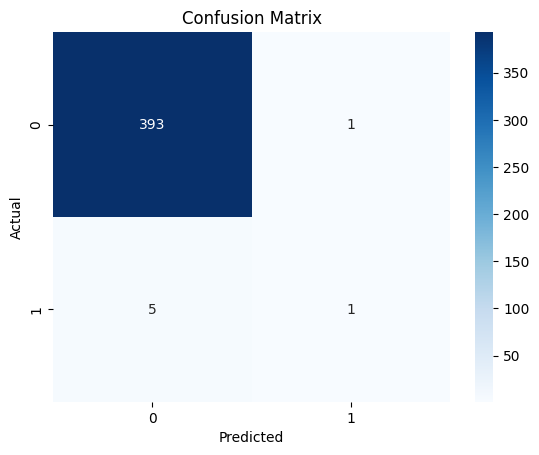

In [63]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Training accuracy/loss
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Testing accuracy/loss
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Task 5: Hyperparameter Experimentation

In [65]:
# Experiment 1 

model1 = Sequential([
    Dense(16, activation='relu', input_dim=X_train.shape[1]),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history1 = model1.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

/Users/sakrak/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [66]:
# Experiment 2

model2 = Sequential([
    Dense(32, activation='relu', input_dim=X_train.shape[1]),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history2 = model2.fit(X_train, y_train, epochs=30, batch_size=16, verbose=0)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

/Users/sakrak/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
# Experiment 3

model3 = Sequential([
    Dense(64, activation='tanh', input_dim=X_train.shape[1]),
    Dense(32, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)

/Users/sakrak/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [68]:
# Comparison Table

# Create comparison table
comparison_table = pd.DataFrame({
    'Experiment': ['Experiment 1', 'Experiment 2', 'Experiment 3'],
    'Hidden Layers': [2, 2, 2],
    'Neurons': ['16, 8', '32, 16', '64, 32'],
    'Activation': ['ReLU', 'ReLU', 'Tanh'],
    'Epochs': [20, 30, 40],
    'Batch Size': [32, 16, 32],
    'Test Accuracy': [acc1, acc2, acc3]
})

# Display table
print(comparison_table)

     Experiment  Hidden Layers Neurons Activation  Epochs  Batch Size  \
0  Experiment 1              2   16, 8       ReLU      20          32   
1  Experiment 2              2  32, 16       ReLU      30          16   
2  Experiment 3              2  64, 32       Tanh      40          32   

   Test Accuracy  
0          0.985  
1          0.985  
2          0.985  


# Task 4 : Final Reflection

In [70]:
print(history.history)

{'accuracy': [0.882031261920929, 0.9781249761581421, 0.96484375, 0.96484375, 0.967968761920929, 0.9671875238418579, 0.9750000238418579, 0.97265625, 0.9765625, 0.98046875, 0.9781249761581421, 0.977343738079071, 0.9781249761581421, 0.979687511920929, 0.981249988079071, 0.9789062738418579, 0.981249988079071, 0.9820312261581421, 0.9820312261581421, 0.9781249761581421, 0.971875011920929, 0.981249988079071, 0.979687511920929, 0.98046875, 0.9789062738418579, 0.975781261920929, 0.98046875, 0.97265625, 0.9828125238418579, 0.979687511920929], 'loss': [2.006800651550293, 0.5461491346359253, 0.32799988985061646, 0.2761504352092743, 0.2648511528968811, 0.16959217190742493, 0.12726929783821106, 0.13519752025604248, 0.13739700615406036, 0.13045290112495422, 0.09891320765018463, 0.11716561019420624, 0.12424899637699127, 0.13199535012245178, 0.09646844863891602, 0.09730032086372375, 0.10847947746515274, 0.0863368883728981, 0.08930454403162003, 0.1629699170589447, 0.15979452431201935, 0.0889336913824081

In [76]:
train_accuracy = history.history['accuracy']

print("Training Accuracy : ", train_accuracy)

Training Accuracy :  [0.882031261920929, 0.9781249761581421, 0.96484375, 0.96484375, 0.967968761920929, 0.9671875238418579, 0.9750000238418579, 0.97265625, 0.9765625, 0.98046875, 0.9781249761581421, 0.977343738079071, 0.9781249761581421, 0.979687511920929, 0.981249988079071, 0.9789062738418579, 0.981249988079071, 0.9820312261581421, 0.9820312261581421, 0.9781249761581421, 0.971875011920929, 0.981249988079071, 0.979687511920929, 0.98046875, 0.9789062738418579, 0.975781261920929, 0.98046875, 0.97265625, 0.9828125238418579, 0.979687511920929]


In [77]:
val_accuracy = history.history['val_accuracy']

print("Validation Accuracy : ", val_accuracy)

Validation Accuracy :  [0.9937499761581421, 0.971875011920929, 0.9468749761581421, 0.9437500238418579, 0.9781249761581421, 0.96875, 0.940625011920929, 0.9937499761581421, 0.9937499761581421, 0.9937499761581421, 0.984375, 0.9937499761581421, 0.9937499761581421, 0.9937499761581421, 0.9937499761581421, 0.9937499761581421, 0.9937499761581421, 0.9937499761581421, 0.9906250238418579, 0.971875011920929, 0.987500011920929, 0.987500011920929, 0.9937499761581421, 0.9937499761581421, 0.9937499761581421, 0.9937499761581421, 0.971875011920929, 0.9937499761581421, 0.9937499761581421, 0.9906250238418579]


In [75]:
# Actual Accuracy
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

0.979687511920929
0.9906250238418579


What role do weights and biases play in the model?
- Weights determine the importance of each input feature.
- Bias helps shift the activation function and improves flexibility.
- During training, the neural network adjusts weights and biases to reduce prediction error.

Why is an activation function required?
- Activation functions introduce non-linearity.

What happens when learning rate is too high or too low?
- If learning rate is too high 
1. Model may skip important values
2. Traning can become unstable

- If learning rate is too low 
1. Model may take too long to conclude results
2. Traning becomes slow

Did your model show signs of underfitting or overfitting? Explain.
- The model did not show strong signs of underfitting or overfitting.
- The training and validation accuracy is quite close indicating that the model was able to learn from training data while also performing well on unseen test data